#### Imports & API Key

In [ ]:
import requests
import pandas as pd
import time
import pyodbc

API_KEY = "Hidden"

# Base headers for Places API (New)
headers = {
    "Content-Type": "application/json",
    "X-Goog-Api-Key": API_KEY,
    "X-Goog-FieldMask": "places.id,places.displayName,places.rating,places.userRatingCount,places.location,places.formattedAddress"
}

# Base URL for nearby search
url = "https://places.googleapis.com/v1/places:searchNearby"

#### Define Fetch Function

In [4]:
def fetch_gyms(lat, lng, radius=4000):
    """
    Fetch gyms around a given latitude/longitude with a specified radius.
    Returns a list of place dictionaries.
    """
    data = {
        "includedTypes": ["gym"],
        "maxResultCount": 20,
        "locationRestriction": {
            "circle": {
                "center": {"latitude": lat, "longitude": lng},
                "radius": radius
            }
        }
    }
    
    response = requests.post(url, headers=headers, json=data)
    
    if response.status_code != 200:
        print(f"Error fetching {lat}, {lng}:", response.text)
        return []
    
    return response.json().get("places", [])

#### Define Anchors for All Areas

In [5]:
anchors = {
    "Markham": [
        (43.8561, -79.3370),  # Central
        (43.9000, -79.3500),  # North
        (43.8200, -79.3300)   # South
    ],
    "Richmond Hill": [
        (43.88, -79.43),      # Central
    ],
    "Scarborough": [
        (43.78, -79.21),      # Central
    ]
}

#### Fetch All Gyms

In [6]:
all_places = []

for area, points in anchors.items():
    for lat, lng in points:
        gyms = fetch_gyms(lat, lng)
        print(f"Fetched {len(gyms)} gyms for {area} anchor {lat}, {lng}")
        all_places.extend(gyms)
        time.sleep(1)  # polite delay to avoid throttling

print("Total raw gyms fetched:", len(all_places))

Fetched 20 gyms for Markham anchor 43.8561, -79.337
Fetched 7 gyms for Markham anchor 43.9, -79.35
Fetched 20 gyms for Markham anchor 43.82, -79.33
Fetched 20 gyms for Richmond Hill anchor 43.88, -79.43
Fetched 20 gyms for Scarborough anchor 43.78, -79.21
Total raw gyms fetched: 87


#### Transform & Deduplicate

In [7]:
rows = []

for place in all_places:
    rows.append({
        "place_id": place.get("id"),
        "name": place.get("displayName", {}).get("text"),
        "rating": place.get("rating"),
        "review_count": place.get("userRatingCount"),
        "latitude": place.get("location", {}).get("latitude"),
        "longitude": place.get("location", {}).get("longitude"),
        "address": place.get("formattedAddress")
    })

# Create DataFrame
df_gyms = pd.DataFrame(rows)

# Deduplicate by place_id
df_gyms = df_gyms.drop_duplicates(subset="place_id")

# Fill missing numeric values
df_gyms["rating"] = df_gyms["rating"].fillna(0.0)
df_gyms["review_count"] = df_gyms["review_count"].fillna(0).astype(int)

# Ensure lat/lng are floats
df_gyms["latitude"] = df_gyms["latitude"].astype(float)
df_gyms["longitude"] = df_gyms["longitude"].astype(float)

print("Unique gyms after deduplication:", len(df_gyms))
df_gyms.head()

Unique gyms after deduplication: 76


,place_id,name,rating,review_count,latitude,longitude,address
0,ChIJsXklsTbU1IkROkiuU4_gqMU,Markham Pan Am Centre,4.6,1593,43.855079,-79.308931,"16 Main St Unionville, Markham, ON L3R 0W7, Ca..."
1,ChIJHYsAIOrU1IkRVu8ux9gIn_c,LA Fitness,3.9,1568,43.851139,-79.356588,"8555 Woodbine Ave, Markham, ON L3R 4X9, Canada"
2,ChIJf0dQfN3U1IkRKU3LDZAYfnQ,Hub Climbing Markham,4.4,684,43.856840,-79.357543,"165 McIntosh Dr, Markham, ON L3R 0N6, Canada"
3,ChIJ87IMn5_V1IkRfdoBfvx4Y6M,Can Sports Center,4.5,267,43.833611,-79.315392,"1443 Denison St, Markham, ON L3R 5V2, Canada"
4,ChIJH_38MlvU1IkR8mDX2-VDmh0,GoodLife Fitness Markham Birchmount and Enterp...,4.1,842,43.849180,-79.323320,"169 Enterprise Blvd, Markham, ON L6G 0E7, Canada"


In [8]:
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=DESKTOP-I86VNM7\\SQLEXPRESS;"
    "DATABASE=GoogleGymAPI;"
    "Trusted_Connection=yes;"
)

cursor = conn.cursor()

for index, row in df_gyms.iterrows():
    cursor.execute("""
        IF NOT EXISTS (SELECT 1 FROM gyms WHERE place_id = ?)
        INSERT INTO gyms (place_id, name, rating, review_count, latitude, longitude, address)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    """,
        row["place_id"],  # for IF check
        row["place_id"],
        row["name"],
        row["rating"],
        row["review_count"],
        row["latitude"],
        row["longitude"],
        row["address"]
    )

conn.commit()
cursor.close()
conn.close()

print("Insert complete for all areas.")

Insert complete for all areas.


In [9]:
df_gyms.head()

,place_id,name,rating,review_count,latitude,longitude,address
0,ChIJsXklsTbU1IkROkiuU4_gqMU,Markham Pan Am Centre,4.6,1593,43.855079,-79.308931,"16 Main St Unionville, Markham, ON L3R 0W7, Ca..."
1,ChIJHYsAIOrU1IkRVu8ux9gIn_c,LA Fitness,3.9,1568,43.851139,-79.356588,"8555 Woodbine Ave, Markham, ON L3R 4X9, Canada"
2,ChIJf0dQfN3U1IkRKU3LDZAYfnQ,Hub Climbing Markham,4.4,684,43.856840,-79.357543,"165 McIntosh Dr, Markham, ON L3R 0N6, Canada"
3,ChIJ87IMn5_V1IkRfdoBfvx4Y6M,Can Sports Center,4.5,267,43.833611,-79.315392,"1443 Denison St, Markham, ON L3R 5V2, Canada"
4,ChIJH_38MlvU1IkR8mDX2-VDmh0,GoodLife Fitness Markham Birchmount and Enterp...,4.1,842,43.849180,-79.323320,"169 Enterprise Blvd, Markham, ON L6G 0E7, Canada"


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

##### Pull Cleaned Data From SQL Server

In [2]:
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=DESKTOP-I86VNM7\\SQLEXPRESS;"
    "DATABASE=GoogleGymAPI;"
    "Trusted_Connection=yes;"
)

df = pd.read_sql("SELECT name, rating, review_count, latitude, longitude, area FROM gyms", conn)
conn.close()

print("Rows loaded:", len(df))
df.head()

Rows loaded: 56


C:\Users\venet\AppData\Local\Temp\ipykernel_16124\2533463772.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT name, rating, review_count, latitude, longitude, area FROM gyms", conn)


,name,rating,review_count,latitude,longitude,area
0,Cowboy Fitness Markham,4.7,60,43.871059,-79.343132,Markham
1,Oasis Fitness,5.0,421,43.837051,-79.320557,Markham
2,OXYGEN Fitness Club,4.9,253,43.834381,-79.355092,Markham
3,Markville Fitness,4.4,236,43.875114,-79.281090,Markham
4,"The Markham Gym - Personal Training, Massage T...",4.8,190,43.875375,-79.278343,Markham


##### Rating Tier Column

In [3]:
def rating_tier(r):
    if r >= 4.5:
        return 'High Tier (4.5+)'
    elif r >= 4.0:
        return 'Mid Tier (4.0–4.49)'
    elif r is None:
        return 'No Rating'
    else:
        return 'Low Tier (<4.0)'

df['rating_tier'] = df['rating'].apply(rating_tier)

##### Market Density Map

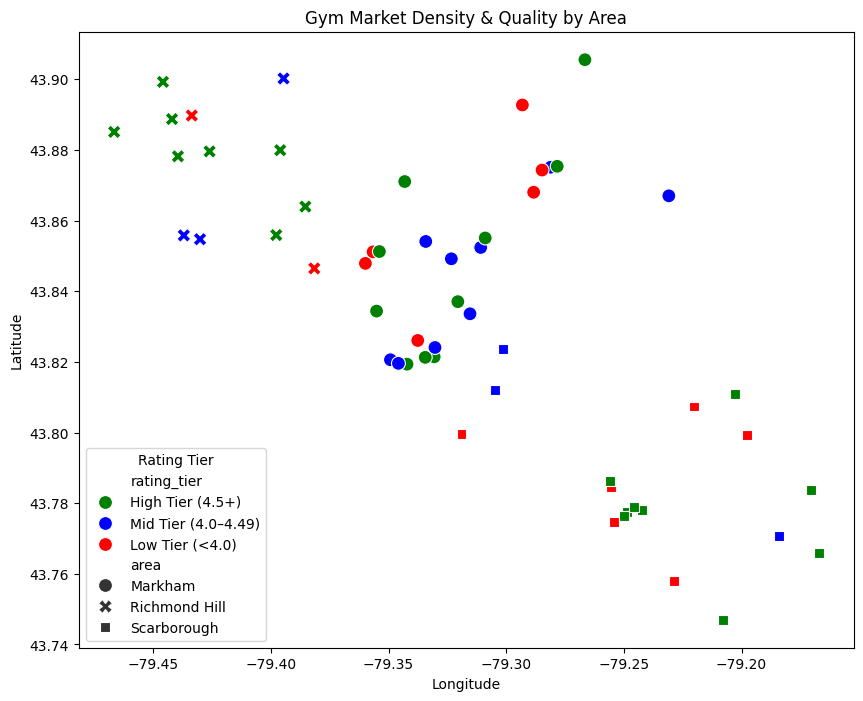

In [4]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df, 
    x='longitude', 
    y='latitude', 
    hue='rating_tier', 
    style='area',
    s=100,
    palette={'High Tier (4.5+)':'green', 'Mid Tier (4.0–4.49)':'blue', 'Low Tier (<4.0)':'red', 'No Rating':'gray'}
)
plt.title('Gym Market Density & Quality by Area')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Rating Tier')
plt.show()

##### Rating vs Review Scatter

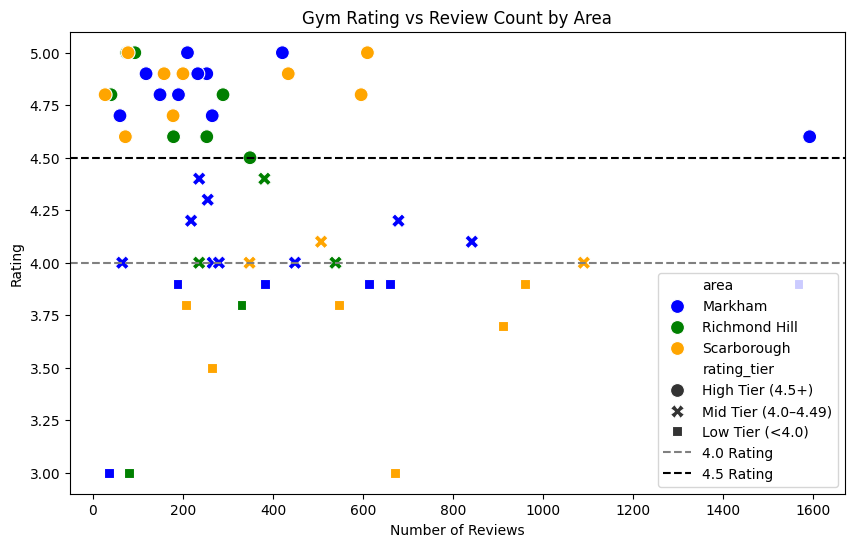

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='review_count',
    y='rating',
    hue='area',
    style='rating_tier',
    s=100,
    palette={'Markham':'blue','Scarborough':'orange','Richmond Hill':'green'}
)
plt.title('Gym Rating vs Review Count by Area')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')
plt.axhline(4.0, color='gray', linestyle='--', label='4.0 Rating')
plt.axhline(4.5, color='black', linestyle='--', label='4.5 Rating')
plt.legend()
plt.show()